In [1]:
import pandas as pd
import sqlite3
import zipfile
import os

# 1. Unzip the archive you uploaded
zip_path = 'archive (2) (1).zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("✅ Successfully unzipped the dataset!")

# 2. Load the newly extracted dataset
df = pd.read_csv('netflix_titles.csv')

# 3. Set up a local SQL database in memory
conn = sqlite3.connect('netflix_analysis.db')
df.to_sql('streaming_catalog', conn, if_exists='replace', index=False)

# 4. Define the SQL Queries required for the project
query_1 = """
-- Query 1: Genre mix volume by release year (Top 10)
SELECT release_year, listed_in AS genre, COUNT(*) as content_count
FROM streaming_catalog
GROUP BY release_year, listed_in
ORDER BY release_year DESC, content_count DESC
LIMIT 10;
"""

query_2 = """
-- Query 2: Maturity rating distribution by country (Top 10)
SELECT country, rating, COUNT(*) as total_titles
FROM streaming_catalog
WHERE country IS NOT NULL AND rating IS NOT NULL
GROUP BY country, rating
ORDER BY total_titles DESC
LIMIT 10;
"""

query_3 = """
-- Query 3: TV Show vs Movie ratio over the last 5 years
SELECT release_year, type, COUNT(*) as volume
FROM streaming_catalog
WHERE release_year >= 2017
GROUP BY release_year, type
ORDER BY release_year DESC;
"""

# 5. Execute a query to make sure it worked!
print("\n--- Result: TV Show vs Movie Ratio ---")
print(pd.read_sql_query(query_3, conn))

# 6. Save the queries to a file for your GitHub submission
with open('aggregations.sql', 'w') as f:
    f.write(query_1 + "\n\n" + query_2 + "\n\n" + query_3)
print("\n✅ Success! 'aggregations.sql' has been created for your portfolio.")

✅ Successfully unzipped the dataset!

--- Result: TV Show vs Movie Ratio ---
   release_year     type  volume
0          2021    Movie     277
1          2021  TV Show     315
2          2020    Movie     517
3          2020  TV Show     436
4          2019    Movie     633
5          2019  TV Show     397
6          2018    Movie     767
7          2018  TV Show     380
8          2017    Movie     767
9          2017  TV Show     265

✅ Success! 'aggregations.sql' has been created for your portfolio.


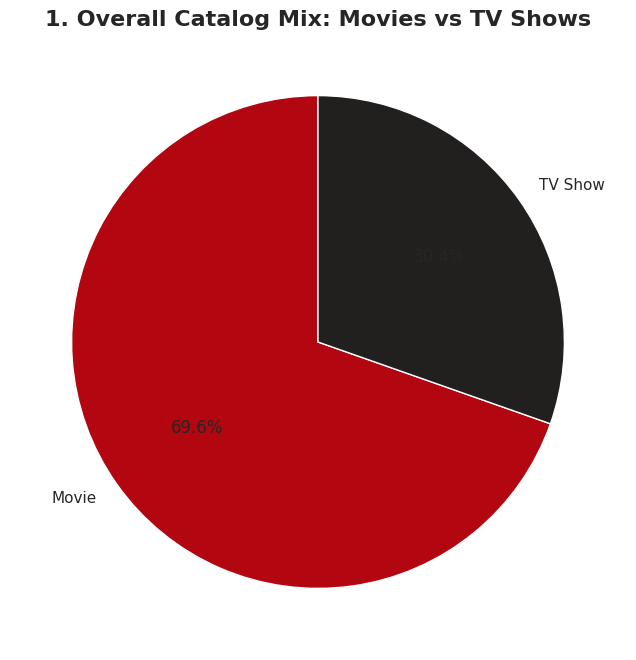

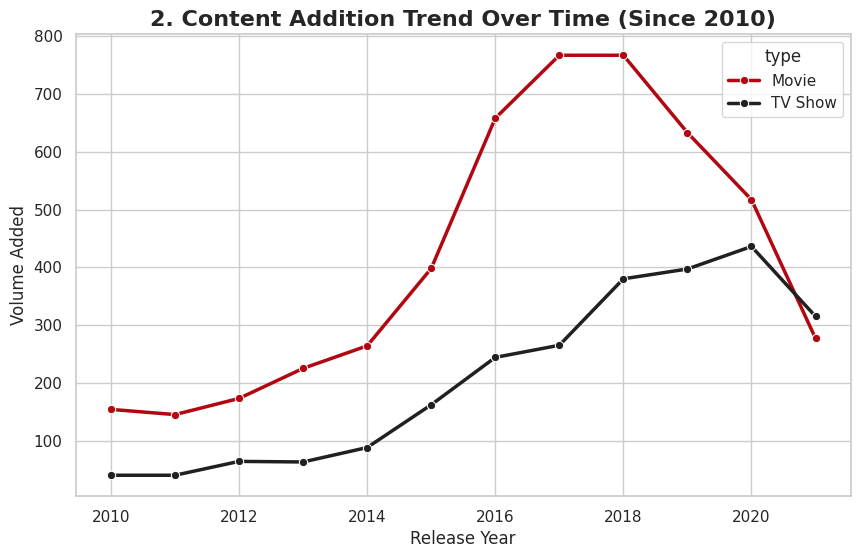

/tmp/ipykernel_1533/2631305467.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_genres.index, x=top_genres.values, palette='viridis')


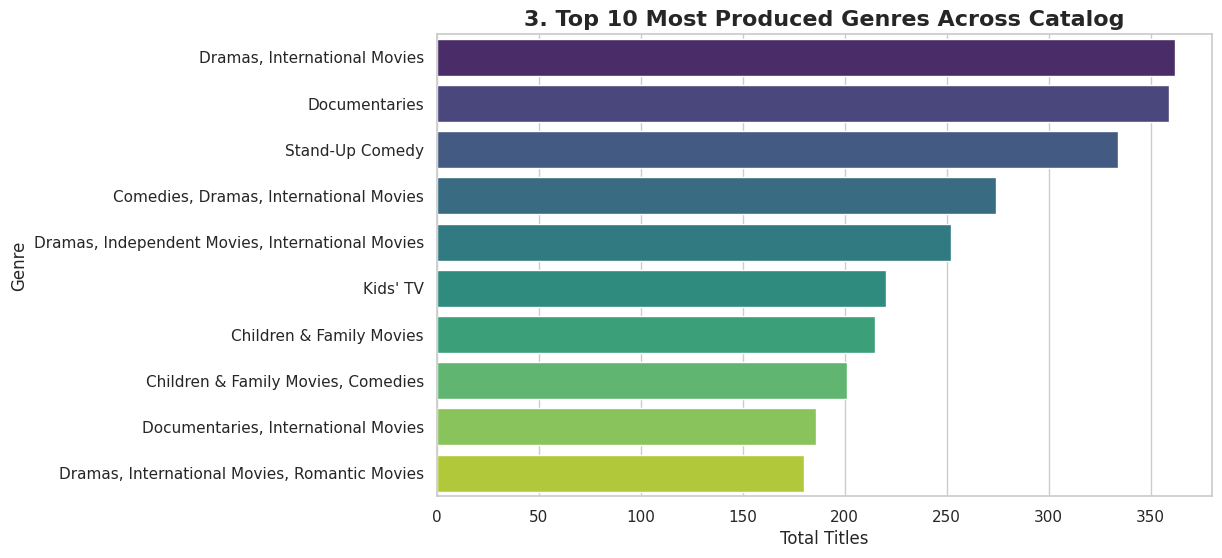

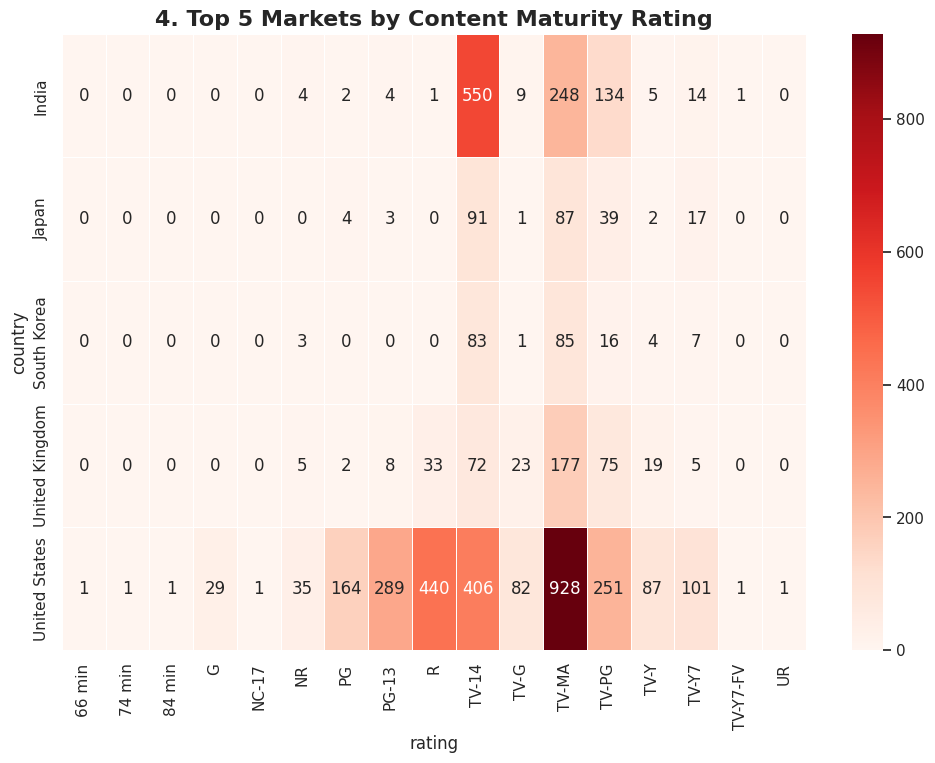

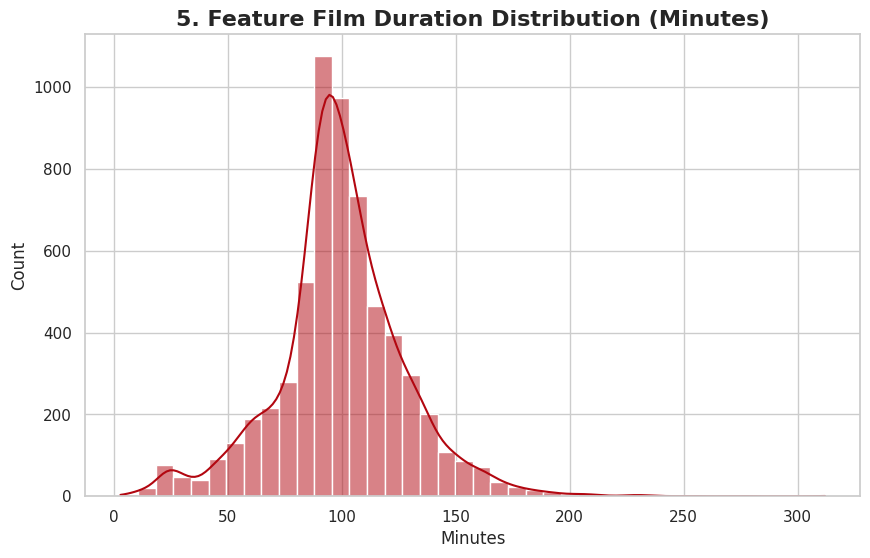

/tmp/ipykernel_1533/2631305467.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='duration_num', data=tv_shows, palette='magma')


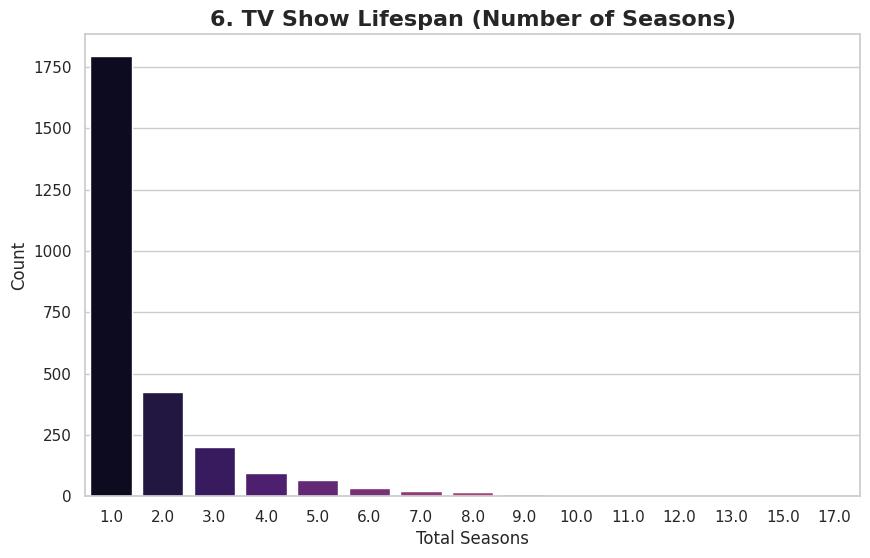

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the dataframe is ready
df = pd.read_csv('netflix_titles.csv')

# Set aesthetic parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Content Type Split (Pie Chart)
plt.figure(figsize=(8, 8))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#b20710', '#221f1f'], startangle=90)
plt.title('1. Overall Catalog Mix: Movies vs TV Shows', fontsize=16, fontweight='bold')
plt.show()

# 2. Release Trend Over Years (Line Chart)
plt.figure()
trend_df = df[df['release_year'] >= 2010].groupby(['release_year', 'type']).size().reset_index(name='count')
sns.lineplot(data=trend_df, x='release_year', y='count', hue='type', palette=['#b20710', '#221f1f'], marker='o', linewidth=2.5)
plt.title('2. Content Addition Trend Over Time (Since 2010)', fontsize=16, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Volume Added')
plt.show()

# 3. Top Genres Globally (Bar Chart)
plt.figure()
top_genres = df['listed_in'].value_counts().head(10)
sns.barplot(y=top_genres.index, x=top_genres.values, palette='viridis')
plt.title('3. Top 10 Most Produced Genres Across Catalog', fontsize=16, fontweight='bold')
plt.xlabel('Total Titles')
plt.ylabel('Genre')
plt.show()

# 4. Regional Maturity Ratings (Heatmap)
plt.figure(figsize=(12, 8))
top_countries = df['country'].value_counts().head(5).index
filtered_rating_df = df[df['country'].isin(top_countries)]
rating_country = pd.crosstab(filtered_rating_df['country'], filtered_rating_df['rating'])
sns.heatmap(rating_country, annot=True, fmt='d', cmap='Reds', linewidths=.5)
plt.title('4. Top 5 Markets by Content Maturity Rating', fontsize=16, fontweight='bold')
plt.show()

# 5. Movie Duration Distribution (Histogram)
plt.figure()
movies = df[df['type'] == 'Movie'].copy()
movies['duration_num'] = movies['duration'].str.replace(' min', '').astype(float)
sns.histplot(movies['duration_num'].dropna(), bins=40, kde=True, color='#b20710')
plt.title('5. Feature Film Duration Distribution (Minutes)', fontsize=16, fontweight='bold')
plt.xlabel('Minutes')
plt.show()

# 6. TV Show Season Count (Count Plot)
plt.figure()
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['duration_num'] = tv_shows['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)
sns.countplot(x='duration_num', data=tv_shows, palette='magma')
plt.title('6. TV Show Lifespan (Number of Seasons)', fontsize=16, fontweight='bold')
plt.xlabel('Total Seasons')
plt.ylabel('Count')
plt.show()